# Notebook 02 – Velozähldaten laden und verarbeiten
**Charge & Ride Züri** | ZHAW Geomarketing FS2026

## Zwei Datenquellen, zwei Abdeckungsgebiete

| | Stadt Zürich | Kanton Zürich |
|---|---|---|
| Zählstellen | ~25 | 97 |
| Abdeckung | Nur Stadtgebiet | Ganzer Kanton |
| Verfügbar seit | 2009 | 2016 |
| Granularität | Viertelstunden | Stunden/Tage |
| Formate | CSV, **Parquet**, PDF | CSV (manuell) |
| Quelle | data.stadt-zuerich.ch | zh.ch Dataset 3062 |

**Strategie:** Kantonsdaten für die räumliche Hauptanalyse (ganzer Kanton),
Stadtdaten für höhere Auflösung im Stadtgebiet.

---

### Daten-URLs (alle verifiziert, CC-Zero / OGD)

**Stadt ZH – Standorte (GeoJSON mit Koordinaten):**
```
https://www.stadt-zuerich.ch/geodaten/download/Standorte_der_automatischen_Fuss__und_Velozaehlungen
```
Formate: CSV, dxf, gpkg, **json (GeoJSON)**, shp, wfs, wms, wmts

**Stadt ZH – Frequenzdaten (Viertelstundenwerte):**
```
https://data.stadt-zuerich.ch/dataset/ted_taz_verkehrszaehlungen_werte_fussgaenger_velo
```
Formate: CSV, **Parquet**, PDF (Korrekturfaktoren)

**Parquet-Download 2025 (deutlich schneller als CSV):**
```
https://data.stadt-zuerich.ch/dataset/ted_taz_verkehrszaehlungen_werte_fussgaenger_velo/download/2025_verkehrszaehlungen_werte_fussgaenger_velo.parquet
```

**Kanton ZH – Velozähldaten (OGD Dataset 3062):**
```
https://www.zh.ch/de/politik-staat/statistik-daten/datenkatalog.html#/datasets/3062@tiefbauamt-kanton-zuerich
```
→ Manueller Download, dann in data/raw/ ablegen

In [11]:
from pathlib import Path
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
import contextily as cx

ROOT = Path('..').resolve()
DATA_RAW = ROOT / 'data' / 'raw'
DATA_PROCESSED = ROOT / 'data' / 'processed'
DATA_RAW.mkdir(parents=True, exist_ok=True)
DATA_PROCESSED.mkdir(parents=True, exist_ok=True)

# Direkte Download-URLs Stadt ZH
BASE_URL = 'https://data.stadt-zuerich.ch/dataset/ted_taz_verkehrszaehlungen_werte_fussgaenger_velo/download/'
URL_PARQUET_2025 = BASE_URL + '2025_verkehrszaehlungen_werte_fussgaenger_velo.parquet'
URL_CSV_2024     = BASE_URL + '2024_verkehrszaehlungen_werte_fussgaenger_velo.csv'

# GeoJSON-Standorte Stadt ZH
URL_STANDORTE_GEOJSON = (
    'https://www.stadt-zuerich.ch/geodaten/download/'
    'Standorte_der_automatischen_Fuss__und_Velozaehlungen?format=geojson'
)

print('Setup abgeschlossen.')

Setup abgeschlossen.


## TEIL A: Frequenzdaten Stadt Zürich laden

Wir laden das **Parquet-Format** – es ist 5-10x schneller als CSV
und benötigt weniger Speicher. Fallback auf CSV falls Parquet fehlt.

In [12]:
# Parquet laden (bevorzugt – schneller und kompakter als CSV)
print('Lade Frequenzdaten (Parquet)...')
try:
    df_freq = pd.read_parquet(URL_PARQUET_2025)
    print(f'Parquet geladen: {df_freq.shape[0]:,} Zeilen, {df_freq.shape[1]} Spalten')
    print(f'Speicherbedarf: {df_freq.memory_usage(deep=True).sum() / 1e6:.1f} MB')
    DATEN_QUELLE = 'Parquet 2025'
except Exception as e:
    print(f'Parquet nicht verfuegbar ({e}), lade CSV als Fallback...')
    df_freq = pd.read_csv(URL_CSV_2024)
    DATEN_QUELLE = 'CSV 2024'
    print(f'CSV geladen: {df_freq.shape[0]:,} Zeilen')

print(f'\nSpalten: {df_freq.columns.tolist()}')
print(f'Datentypen:')
print(df_freq.dtypes)
df_freq.head(3)

Lade Frequenzdaten (Parquet)...
Parquet nicht verfuegbar (HTTP Error 500: INTERNAL SERVER ERROR), lade CSV als Fallback...
CSV geladen: 918,210 Zeilen

Spalten: ['FK_STANDORT', 'DATUM', 'VELO_IN', 'VELO_OUT', 'FUSS_IN', 'FUSS_OUT', 'OST', 'NORD']
Datentypen:
FK_STANDORT      int64
DATUM              str
VELO_IN        float64
VELO_OUT       float64
FUSS_IN        float64
FUSS_OUT       float64
OST              int64
NORD             int64
dtype: object


,FK_STANDORT,DATUM,VELO_IN,VELO_OUT,FUSS_IN,FUSS_OUT,OST,NORD
0,4267,2024-01-01T00:00,0.0,NaN,NaN,NaN,2683457,1247065
1,4270,2024-01-01T00:00,0.0,1.0,NaN,NaN,2684006,1246566
2,2989,2024-01-01T00:00,3.0,2.0,NaN,NaN,2682278,1248324


In [13]:
# Datenstruktur erkunden
# WICHTIG: Das CSV/Parquet enthaelt SOWOHL Velo- ALS AUCH Fussgaengerzaehlstellen!

print('=== Spaltenstruktur ===')
for col in df_freq.columns:
    n_unique = df_freq[col].nunique()
    if n_unique < 30:
        print(f'  {col} ({n_unique} Werte): {sorted(df_freq[col].dropna().unique().tolist())[:10]}')
    else:
        print(f'  {col}: {n_unique} eindeutige Werte (Beispiel: {df_freq[col].iloc[0]})')

# Hinweis: Der Join-Schluessel heisst FK_ZAEHLER im Datensatz
# und verbindet mit dem Geodatensatz

=== Spaltenstruktur ===
  FK_STANDORT (27 Werte): [732, 1037, 2982, 2986, 2989, 2991, 2993, 2997, 3003, 3012]
  DATUM: 35132 eindeutige Werte (Beispiel: 2024-01-01T00:00)
  VELO_IN: 225 eindeutige Werte (Beispiel: 0.0)
  VELO_OUT: 174 eindeutige Werte (Beispiel: nan)
  FUSS_IN: 218 eindeutige Werte (Beispiel: nan)
  FUSS_OUT: 161 eindeutige Werte (Beispiel: nan)
  OST (27 Werte): [2679767, 2681301, 2681319, 2681339, 2681857, 2682147, 2682227, 2682278, 2682296, 2682297]
  NORD (27 Werte): [1244140, 1244618, 1245891, 1246549, 1246566, 1247055, 1247063, 1247065, 1247199, 1247323]


In [14]:
# Nur Zeilen mit Velodaten behalten
# Das CSV 2024 hat keine Typ-Spalte: Velostellen erkennt man daran,
# dass VELO_IN oder VELO_OUT einen Wert hat (FUSS_IN/OUT = NaN bei reinen Velostellen)
df_velo = df_freq[df_freq[['VELO_IN', 'VELO_OUT']].notna().any(axis=1)].copy()
print(f'Gesamt: {len(df_freq):,} Zeilen -> Mit Velodaten: {len(df_velo):,} Zeilen')

# Datum parsen (Format: '2024-01-01T00:00')
df_velo['DATUM'] = pd.to_datetime(df_velo['DATUM'])
df_velo['datum_tag'] = df_velo['DATUM'].dt.date

print(f'Zeitraum: {df_velo["DATUM"].min()} bis {df_velo["DATUM"].max()}')
print(f'Zählstellen: {df_velo["FK_STANDORT"].nunique()}')

Gesamt: 918,210 Zeilen -> Mit Velodaten: 816,843 Zeilen
Zeitraum: 2024-01-01 00:00:00 bis 2024-12-31 23:45:00
Zählstellen: 24


In [15]:
# Velo-Gesamtmenge pro Zeile: VELO_IN + VELO_OUT (beide Richtungen)
# min_count=1: NaN nur wenn BEIDE Richtungen fehlen
df_velo['velos_total'] = df_velo[['VELO_IN', 'VELO_OUT']].sum(axis=1, min_count=1)

# Tagesfrequenz pro Zählstelle (Viertelstunden-/Stundenwerte summieren)
df_daily = (
    df_velo
    .groupby(['FK_STANDORT', 'datum_tag'])['velos_total']
    .sum()
    .reset_index()
)

# DTV = Mittelwert der Tagesfrequenzen
df_dtv = (
    df_daily
    .groupby('FK_STANDORT')['velos_total']
    .agg(dtv_velos='mean', max_tag='max', anzahl_tage='count')
    .reset_index()
)

print('Top-10 Zählstellen nach mittlerem Tagesverkehr (DTV):')
print(df_dtv.sort_values('dtv_velos', ascending=False).head(10).to_string(index=False))

Top-10 Zählstellen nach mittlerem Tagesverkehr (DTV):
 FK_STANDORT   dtv_velos  max_tag  anzahl_tage
        2989 3579.142077   7328.0          366
        4249 3230.051913   8398.0          366
        1037 2587.595628   5651.0          366
        4266 2234.713115   5389.0          366
        4267 2139.155738   4263.0          366
        4259 1944.819672   4107.0          366
        4270 1851.262295   3838.0          366
        5002 1756.573770   6033.0          366
        2993 1546.729508   3199.0          366
        3012 1412.259563   3147.0          366


## TEIL B: Standorte (GeoJSON) laden und mit Frequenzen joinen

In [16]:
# Standorte direkt aus dem CSV erstellen
# Das CSV enthält bereits Koordinaten: OST/NORD in LV95 (EPSG:2056)
# -> kein separater GeoJSON-Download nötig

df_standorte = (
    df_freq[['FK_STANDORT', 'OST', 'NORD']]
    .drop_duplicates(subset='FK_STANDORT')
)

gdf_standorte = gpd.GeoDataFrame(
    df_standorte,
    geometry=gpd.points_from_xy(df_standorte['OST'], df_standorte['NORD']),
    crs='EPSG:2056'
)

print(f'Standorte: {len(gdf_standorte)} Einträge')
print(f'CRS: {gdf_standorte.crs}')

Standorte: 27 Einträge
CRS: EPSG:2056


In [17]:
# Join: Standorte + DTV-Frequenzen
# Join-Schlüssel: FK_STANDORT

gdf_standorte['FK_STANDORT'] = gdf_standorte['FK_STANDORT'].astype(str)
df_dtv['FK_STANDORT'] = df_dtv['FK_STANDORT'].astype(str)

gdf_mit_dtv = gdf_standorte.merge(df_dtv, on='FK_STANDORT', how='left')

print(f'Zählstellen: {len(gdf_mit_dtv)}')
print(f'Davon mit DTV-Daten: {gdf_mit_dtv["dtv_velos"].notna().sum()}')

# Als GeoJSON speichern (WGS84 für GeoJSON-Standard)
gdf_mit_dtv.to_crs(epsg=4326).to_file(
    DATA_PROCESSED / 'velozaehlstellen_stadt_zh.geojson',
    driver='GeoJSON'
)
print('Gespeichert: data/processed/velozaehlstellen_stadt_zh.geojson')

Zählstellen: 27
Davon mit DTV-Daten: 24
Gespeichert: data/processed/velozaehlstellen_stadt_zh.geojson


## TEIL C: Kantonale Velozählstellen (Dataset 3062)

Datenquelle: Tiefbauamt Kanton Zürich, OGD Dataset 3062  
Datei: `data/raw/verkehrszaehldaten_velo_kanton_zh_2024.csv`  
Format: CSV, UTF-8, Komma-getrennt  
Granularität: **Stundenwerte** (24 Intervalle pro Tag, mehrere Richtungen pro Messstelle)  
Koordinaten: direkt im CSV (WGS84/EPSG:4326), kein separates Geodaten-File nötig  
Hinweis: Rohdaten, nicht plausibilisiert (laut Dokumentation)

In [18]:
# Kantonale Velozähldaten laden
# Quelle: Tiefbauamt Kanton ZH, OGD Dataset 3062
# Encoding laut Dokumentation UTF-8; Fallback auf latin-1 für ältere Exports

CSV_KANTON = DATA_RAW / 'verkehrszaehldaten_velo_kanton_zh_2024.csv'

try:
    df_kanton = pd.read_csv(CSV_KANTON, encoding='utf-8')
    print(f'Geladen mit UTF-8: {df_kanton.shape[0]:,} Zeilen, {df_kanton.shape[1]} Spalten')
except UnicodeDecodeError:
    df_kanton = pd.read_csv(CSV_KANTON, encoding='latin-1')
    print(f'Geladen mit latin-1 (Fallback): {df_kanton.shape[0]:,} Zeilen')

print(f'Spalten: {df_kanton.columns.tolist()}')
df_kanton.head(3)

Geladen mit UTF-8: 1,563,336 Zeilen, 10 Spalten
Spalten: ['datum', 'zeit_von', 'zeit_bis', 'gemeinde', 'raumplanungsregion', 'anzahl_velos', 'spur_richtung', 'messstelle_id', 'messstelle_laengengrad_WGS84', 'messstelle_breitengrad_WGS84']


,datum,zeit_von,zeit_bis,gemeinde,raumplanungsregion,anzahl_velos,spur_richtung,messstelle_id,messstelle_laengengrad_WGS84,messstelle_breitengrad_WGS84
0,2025-01-01,2025-01-01T00:00:00+01,2025-01-01T00:59:59+01,Horgen,Zimmerberg,0,Horgen,523,8.618849,47.253654
1,2025-01-01,2025-01-01T01:00:00+01,2025-01-01T01:59:59+01,Horgen,Zimmerberg,0,Horgen,523,8.618849,47.253654
2,2025-01-01,2025-01-01T02:00:00+01,2025-01-01T02:59:59+01,Horgen,Zimmerberg,0,Horgen,523,8.618849,47.253654


In [19]:
# Spaltenstruktur und Datenqualität erkunden
print('=== Spaltenübersicht ===')
for col in df_kanton.columns:
    n_unique = df_kanton[col].nunique()
    if n_unique < 20:
        beispiele = sorted(df_kanton[col].dropna().unique().tolist())[:10]
        print(f'  {col} ({n_unique} Werte): {beispiele}')
    else:
        print(f'  {col}: {n_unique} eindeutige Werte  (Beispiel: {df_kanton[col].iloc[0]})')

print(f'\nMessstellen total:  {df_kanton["messstelle_id"].nunique()}')
print(f'Zeitraum:           {df_kanton["datum"].min()}  bis  {df_kanton["datum"].max()}')
print(f'Fehlende Werte:\n{df_kanton.isnull().sum()}')

=== Spaltenübersicht ===
  datum: 365 eindeutige Werte  (Beispiel: 2025-01-01)
  zeit_von: 8760 eindeutige Werte  (Beispiel: 2025-01-01T00:00:00+01)
  zeit_bis: 8760 eindeutige Werte  (Beispiel: 2025-01-01T00:59:59+01)
  gemeinde: 46 eindeutige Werte  (Beispiel: Horgen)
  raumplanungsregion (11 Werte): ['Furttal', 'Glattal', 'Knonaueramt', 'Limmattal', 'Pfannenstiel', 'Stadt Zürich', 'Weinland', 'Winterthur und Umgebung', 'Zimmerberg', 'Zürcher Oberland']
  anzahl_velos: 244 eindeutige Werte  (Beispiel: 0)
  spur_richtung: 105 eindeutige Werte  (Beispiel: Horgen)
  messstelle_id: 97 eindeutige Werte  (Beispiel: 523)
  messstelle_laengengrad_WGS84: 97 eindeutige Werte  (Beispiel: 8.618849128063152)
  messstelle_breitengrad_WGS84: 97 eindeutige Werte  (Beispiel: 47.25365358150552)

Messstellen total:  97
Zeitraum:           2025-01-01  bis  2025-12-31
Fehlende Werte:
datum                           0
zeit_von                        0
zeit_bis                        0
gemeinde            

In [20]:
# DTV (Durchschnittlicher Tagesverkehr) pro Messstelle berechnen
# Datenstruktur: Stundenwerte + mehrere Richtungen (spur_richtung) pro Stunde
#
# Vorgehen:
#   1. Alle Richtungen einer Messstelle pro Tag summieren  -> Tagesfrequenz
#   2. Mittelwert über alle verfügbaren Tage              -> DTV

# Schritt 1: Tagesfrequenz je Messstelle (alle Richtungen addiert)
df_kanton_daily = (
    df_kanton
    .groupby(['messstelle_id', 'datum'])['anzahl_velos']
    .sum()
    .reset_index()
    .rename(columns={'anzahl_velos': 'tages_total'})
)

# Schritt 2: DTV = Mittelwert der Tagesfrequenzen
df_kanton_dtv = (
    df_kanton_daily
    .groupby('messstelle_id')['tages_total']
    .agg(dtv_velos='mean', max_tag='max', anzahl_tage='count')
    .reset_index()
)

print(f'Messstellen mit DTV: {len(df_kanton_dtv)}')
print('\nTop-10 Messstellen nach DTV:')
print(df_kanton_dtv.sort_values('dtv_velos', ascending=False).head(10).to_string(index=False))

Messstellen mit DTV: 97

Top-10 Messstellen nach DTV:
 messstelle_id  dtv_velos  max_tag  anzahl_tage
          5222 875.756164     1582          365
          1119 858.539726     5698          365
          2119 748.600000     1570          365
           818 721.701370     1603          365
          2020 692.772603     1786          365
          5019 586.833333     1269          282
          1519 555.287671     1440          365
          4721 502.202740     3593          365
          2220 493.545205     1058          365
           918 479.800000      981          365


In [21]:
# GeoDataFrame aus X/Y-Koordinaten erstellen
# Die Koordinaten (WGS84) sind direkt im CSV enthalten und pro Messstelle identisch
# -> eine Zeile pro Messstelle extrahieren und mit DTV-Daten joinen

df_kanton_coords = (
    df_kanton[['messstelle_id', 'gemeinde', 'raumplanungsregion',
               'messstelle_laengengrad_WGS84', 'messstelle_breitengrad_WGS84']]
    .drop_duplicates(subset='messstelle_id')
)

# DTV joinen
df_kanton_merged = df_kanton_coords.merge(df_kanton_dtv, on='messstelle_id', how='left')

# GeoDataFrame in WGS84 (Längengrad = x, Breitengrad = y)
gdf_kanton_stationen = gpd.GeoDataFrame(
    df_kanton_merged,
    geometry=gpd.points_from_xy(
        df_kanton_merged['messstelle_laengengrad_WGS84'],
        df_kanton_merged['messstelle_breitengrad_WGS84']
    ),
    crs='EPSG:4326'
)

# In LV95 umrechnen für Distanzberechnungen in Metern (Notebook 03)
gdf_kanton_stationen_lv95 = gdf_kanton_stationen.to_crs(epsg=2056)
print(f'Messstellen: {len(gdf_kanton_stationen_lv95)}')
print(f'CRS (Arbeit): {gdf_kanton_stationen_lv95.crs}')

# Als GeoJSON speichern (WGS84, GeoJSON-Standard)
OUTPUT = DATA_PROCESSED / 'velozaehlstellen_kanton_zh.geojson'
gdf_kanton_stationen.to_file(OUTPUT, driver='GeoJSON')
print(f'Gespeichert: {OUTPUT}')

Messstellen: 97
CRS (Arbeit): EPSG:2056
Gespeichert: /Users/iliasehrensperger/Desktop/Local Files/Github Clones/ChargeAndRideZuerich/data/processed/velozaehlstellen_kanton_zh.geojson


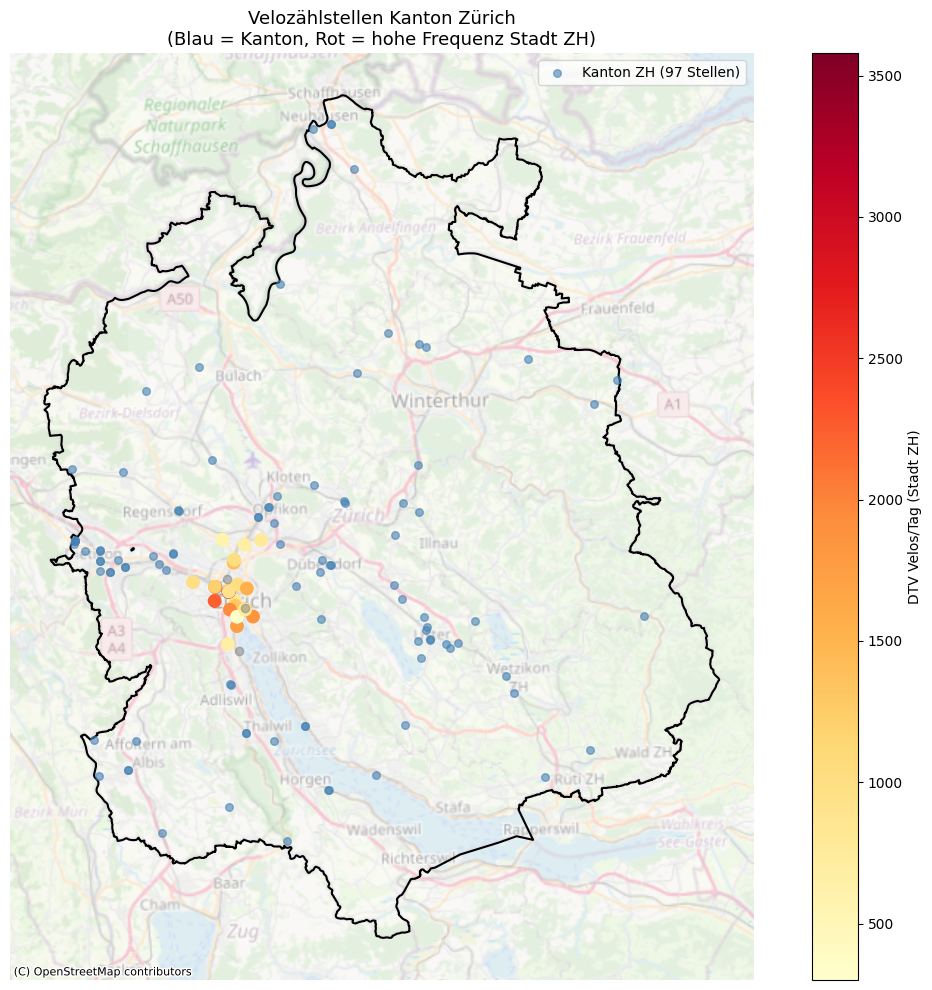

Karte 1 gespeichert.


In [22]:
fig, ax = plt.subplots(figsize=(12, 10))

# Kantonsgrenze
gdf_kanton_boundary = gpd.read_file(DATA_PROCESSED / 'kanton_zh_boundary.geojson').to_crs(epsg=2056)
gdf_kanton_boundary.boundary.plot(ax=ax, color='black', linewidth=1.5, zorder=3)

# Kanton ZH Messstellen (grau, kleiner)
gdf_kanton_stationen_lv95.plot(
    ax=ax,
    color='steelblue',
    markersize=30,
    alpha=0.6,
    label='Kanton ZH (97 Stellen)',
    zorder=4
)

# Stadt ZH Zaehlstellen (farbig nach DTV)
gdf_mit_dtv.plot(
    ax=ax,
    column='dtv_velos',
    cmap='YlOrRd',
    markersize=80,
    legend=True,
    legend_kwds={'label': 'DTV Velos/Tag (Stadt ZH)'},
    zorder=5,
    missing_kwds={'color': 'grey', 'alpha': 0.5}
)

cx.add_basemap(ax, crs='EPSG:2056', source=cx.providers.OpenStreetMap.Mapnik, alpha=0.4)
ax.legend(fontsize=10)
ax.set_title('Velozählstellen Kanton Zürich\n(Blau = Kanton, Rot = hohe Frequenz Stadt ZH)', fontsize=13)
ax.set_axis_off()
plt.tight_layout()
plt.savefig(DATA_PROCESSED / 'karte1_velozaehlstellen_frequenz.png', dpi=150, bbox_inches='tight')
plt.show()
print('Karte 1 gespeichert.')

## Zusammenfassung

| Datensatz | Format | Zählstellen | Output |
|---|---|---|---|
| Stadt ZH Frequenzen | Parquet (schnell!) | 25 | `velozaehlstellen_stadt_zh.geojson` |
| Kanton ZH Frequenzen | CSV (Stundenwerte) | 97 | `velozaehlstellen_kanton_zh.geojson` |

→ Weiter mit **Notebook 03** (Scoring-Modell)